<a href="https://colab.research.google.com/github/SitiMutmainah15/PEMBELAJARAN-MESIN_GENAP_2026/blob/main/JS06/TugasLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

no 1

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/voice (1).csv')

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [ ]:
print("Ukuran dataset:", df.shape)
print("\nMissing value:")
print(df.isnull().sum())

print("\nJumlah setiap label:")
print(df['label'].value_counts())

Ukuran dataset: (3168, 21)

Missing value:
meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64

Jumlah setiap label:
label
male      1584
female    1584
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

print("Hasil encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

df.head()

Hasil encoding:
{'female': np.int64(0), 'male': np.int64(1)}


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,1
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,1
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,1
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,1
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,1


In [ ]:
X = df.drop(columns=['label'])
y = df['label']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (3168, 20)
Shape y: (3168,)


In [ ]:
# Split 70:30
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Split 80:20
X_train80, X_test80, y_train80, y_test80 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split 70:30")
print(len(X_train70), len(X_test70))

print("\nSplit 80:20")
print(len(X_train80), len(X_test80))

Split 70:30
2217 951

Split 80:20
2534 634


In [ ]:
hasil = []

data_split = {
    '70:30': (X_train70, X_test70, y_train70, y_test70),
    '80:20': (X_train80, X_test80, y_train80, y_test80)
}

for split, (X_train, X_test, y_train, y_test) in data_split.items():

    for kernel in ['linear', 'poly', 'rbf']:

        model = make_pipeline(
            StandardScaler(),
            SVC(kernel=kernel)
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        akurasi = accuracy_score(y_test, y_pred)

        hasil.append({
            'Split Data': split,
            'Kernel': kernel,
            'Akurasi (%)': round(akurasi * 100, 2)
        })

In [ ]:
hasil_df = pd.DataFrame(hasil)

display(hasil_df)

,Split Data,Kernel,Akurasi (%)
0,70:30,linear,97.90
1,70:30,poly,96.00
2,70:30,rbf,98.32
3,80:20,linear,97.48
4,80:20,poly,95.58
5,80:20,rbf,98.26


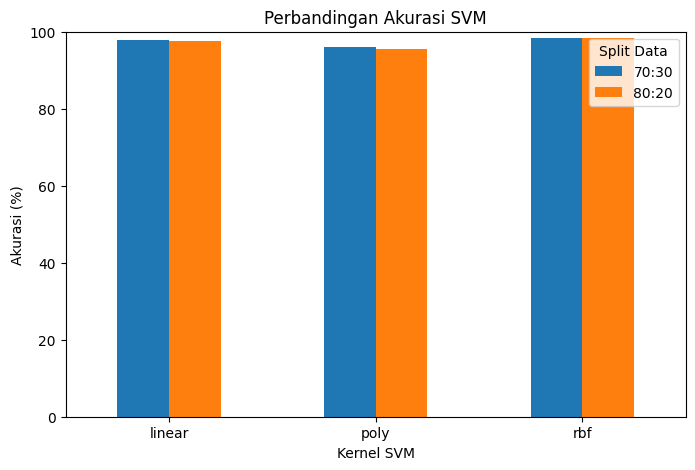

In [ ]:
import matplotlib.pyplot as plt

pivot = hasil_df.pivot(
    index='Kernel',
    columns='Split Data',
    values='Akurasi (%)'
)

pivot.plot(kind='bar', figsize=(8, 5))

plt.title('Perbandingan Akurasi SVM')
plt.xlabel('Kernel SVM')
plt.ylabel('Akurasi (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title='Split Data')
plt.show()

In [ ]:
model_terbaik = hasil_df.loc[
    hasil_df['Akurasi (%)'].idxmax()
]

print("Model dengan akurasi tertinggi:")
print(model_terbaik)

Model dengan akurasi tertinggi:
Split Data     70:30
Kernel           rbf
Akurasi (%)    98.32
Name: 2, dtype: object


Penggunaan kernel dan rasio pembagian data memberikan hasil akurasi yang berbeda. Kernel RBF dengan 70:30 menunjukkan performa terbaik dalam mengklasifikasikan data suara dibandingkan kombinasi model lainnya.

no 2

In [3]:
import cv2

def standardized_input(image):
    return cv2.resize(image, (1100, 600))

def preprocess(image_list):
    standardized_list = []

    for image, label in image_list:
        standardized_image = standardized_input(image)
        standardized_list.append((standardized_image, label))

    return standardized_list

In [4]:
print("train_img tersedia:", 'train_img' in globals())

train_img tersedia: False


In [5]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [9]:
import zipfile

with zipfile.ZipFile('/content/images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [10]:
import os
import cv2

train_img = []

dataset_path = '/content/images/training'

for label in ['day', 'night']:
    folder = os.path.join(dataset_path, label)

    for filename in os.listdir(folder):
        image_path = os.path.join(folder, filename)

        image = cv2.imread(image_path)

        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            train_img.append((image, label))

print("Jumlah gambar:", len(train_img))

Jumlah gambar: 240


In [11]:
train_std_img_list = preprocess(train_img)

print("Jumlah data:", len(train_std_img_list))
print("Shape gambar:", train_std_img_list[0][0].shape)
print("Label:", train_std_img_list[0][1])

Jumlah data: 240
Shape gambar: (600, 1100, 3)
Label: day


In [12]:
import numpy as np
import cv2

def extract_histogram(image):
    features = []

    for channel in range(3):
        hist = cv2.calcHist(
            [image], [channel], None, [256], [0, 256]
        )

        hist = cv2.normalize(hist, hist).flatten()
        features.extend(hist)

    return np.array(features)

X = []
y = []

for image, label in train_std_img_list:
    X.append(extract_histogram(image))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape fitur:", X.shape)
print("Shape label:", y.shape)
print("Jumlah setiap kelas:")
print(np.unique(y, return_counts=True))

Shape fitur: (240, 768)
Shape label: (240,)
Jumlah setiap kelas:
(array(['day', 'night'], dtype='<U5'), array([120, 120]))


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 192
Jumlah data testing: 48


In [14]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Membuat model SVM dengan kernel RBF
model_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)

# Training model
model_rbf.fit(X_train, y_train)

# Prediksi data testing
y_pred = model_rbf.predict(X_test)

# Menghitung akurasi
akurasi = accuracy_score(y_test, y_pred)

print(f"Akurasi SVM RBF: {akurasi * 100:.2f}%")

Akurasi SVM RBF: 100.00%


In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf')
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# Training dan pencarian parameter terbaik
grid.fit(X_train, y_train)

# Prediksi menggunakan model terbaik
y_pred_tuned = grid.predict(X_test)

# Menghitung akurasi
akurasi_tuned = accuracy_score(y_test, y_pred_tuned)

print("Parameter terbaik:", grid.best_params_)
print(f"Akurasi setelah tuning: {akurasi_tuned * 100:.2f}%")

Parameter terbaik: {'svc__C': 1, 'svc__gamma': 'scale'}
Akurasi setelah tuning: 100.00%


In [16]:
import pandas as pd

hasil_tugas2 = pd.DataFrame({
    'Model': ['SVM RBF', 'SVM RBF Tuning'],
    'Split Data': ['80:20', '80:20'],
    'Fitur': ['Histogram RGB', 'Histogram RGB'],
    'Akurasi (%)': [
        round(akurasi * 100, 2),
        round(akurasi_tuned * 100, 2)
    ]
})

display(hasil_tugas2)

,Model,Split Data,Fitur,Akurasi (%)
0,SVM RBF,80:20,Histogram RGB,100.0
1,SVM RBF Tuning,80:20,Histogram RGB,100.0


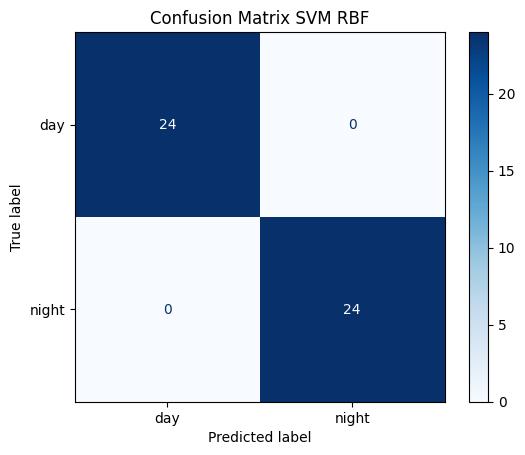

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    cmap='Blues'
)

plt.title('Confusion Matrix SVM RBF')
plt.show()

Model SVM dengan kernel RBF menggunakan fitur histogram RGB mendapat akurasi 100% dengan pembagian 80:20. Setelah dilakukan hyperparameter tuning, hasilnya tetap 100%. Dari hasil tersebut, seluruh gambar siang dan malam pada data pengujian berhasil diklasifikasikan dengan benar. Sehingga penggunaan parameter awal sudah memberikan hasil yang baik sehingga proses tuning belum menunjukkan adanya peningkatan akurasi.